# Student Performance Prediction Project 


In [94]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [95]:
import os

print("Current notebook folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir("."))

print("\nFiles in parent folder:")
print(os.listdir(".."))

print("\nFiles in data folder:")
print(os.listdir("../data"))

Current notebook folder:
d:\documents projects\student_performance _predictionmodel\notebook

Files in current folder:
['app.py', 'student_performance_prediction.ipynb']

Files in parent folder:
['.venv', 'data', 'models', 'notebook', 'outputs']

Files in data folder:
['student performance on an entrance examination.csv']


In [96]:
import os

file_path = "../data/student performance on an entrance examination.csv"

print("File exists:", os.path.exists(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

with open(file_path, "rb") as f:
    content = f.read(500)

print("\nFirst 500 bytes:")
print(content)

File exists: True
File size: 74388 bytes

First 500 bytes:
b'@RELATION,CEEData,,\r\n\r\n@ATTRIBUTE,\'Performance\',"{\'Excellent\',\'Vg\',\'Good\',\'Average\'}",\r\n@ATTRIBUTE,\'Gender\',"{\'male\',\'female\'}",\r\n@ATTRIBUTE,\'Caste\',"{\'General\',\'OBC\',\'SC\',\'ST\'}",\r\n@ATTRIBUTE,\'coaching\',"{\'NO\',\'WA\',\'OA\'}",\r\n@ATTRIBUTE,\'time\',"{\'ONE\',\'TWO\',\'THREE\',\'FOUR\',\'FIVE\',\'SEVEN\'}",\r\n@ATTRIBUTE,\'Class_ten_education\',"{\'SEBA\',\'OTHERS\',\'CBSE\'}",\r\n@ATTRIBUTE,\'twelve_education\',"{\'AHSEC\',\'CBSE\',\'OTHERS\'}",\r\n@ATTRIBUTE,\'medium\',"{\'ENGLISH\',\'OTHERS\',\'ASSAMESE\'}",\r\n@ATTRIBUTE,\'Class_,X_Percentage\''


In [97]:
import os

file_path = "../data/student performance on an entrance examination.csv"

print("File exists:", os.path.exists(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

File exists: True
File size: 74388 bytes


In [98]:
import pandas as pd

file_path = "../data/student performance on an entrance examination.csv"

df = pd.read_csv(
    file_path,
    skiprows=14,
    header=None
)

print("Dataset shape:", df.shape)

Dataset shape: (667, 4)


In [99]:
print(df.head(10).to_string())

                                                                                                                           0   1   2   3
0                                                                                                                      @DATA NaN NaN NaN
1                 'Excellent','male','General','NO','ONE','SEBA','AHSEC','ENGLISH','Excellent','Excellent','DOCTOR','OTHERS' NaN NaN NaN
2          'Excellent','male','OBC','WA','TWO','SEBA','AHSEC','OTHERS','Excellent','Excellent','SCHOOL_TEACHER','HOUSE_WIFE' NaN NaN NaN
3              'Excellent','male','OBC','OA','TWO','OTHERS','CBSE','ENGLISH','Excellent','Excellent','BUSINESS','HOUSE_WIFE' NaN NaN NaN
4  'Excellent','male','General','WA','ONE','SEBA','AHSEC','OTHERS','Excellent','Excellent','SCHOOL_TEACHER','SCHOOL_TEACHER' NaN NaN NaN
5     'Excellent','male','General','OA','TWO','SEBA','CBSE','ENGLISH','Excellent','Excellent','COLLEGE_TEACHER','HOUSE_WIFE' NaN NaN NaN
6     'Excellent','male','General','WA','

In [100]:
print(df.tail(5).to_string())

                                                                                                           0   1   2   3
662            'Average','female','ST','WA','ONE','SEBA','AHSEC','ENGLISH','Good','Vg','OTHERS','HOUSE_WIFE' NaN NaN NaN
663        'Average','male','ST','WA','THREE','SEBA','AHSEC','ENGLISH','Vg','Good','CULTIVATOR','HOUSE_WIFE' NaN NaN NaN
664           'Average','male','ST','WA','TWO','SEBA','CBSE','ENGLISH','Good','Vg','OTHERS','SCHOOL_TEACHER' NaN NaN NaN
665  'Average','male','ST','WA','THREE','SEBA','AHSEC','ENGLISH','Good','Good','SCHOOL_TEACHER','HOUSE_WIFE' NaN NaN NaN
666               'Average','female','ST','NO','ONE','SEBA','CBSE','ENGLISH','Vg','Good','BUSINESS','OTHERS' NaN NaN NaN


In [101]:
import pandas as pd
import re

file_path = "../data/student performance on an entrance examination.csv"

# Read the complete file
with open(file_path, "r", encoding="utf-8-sig") as f:
    lines = f.readlines()

# Find the @DATA line
data_start = None

for i, line in enumerate(lines):
    if "@DATA" in line.upper():
        data_start = i + 1
        break

print("Data starts at line:", data_start)

# Column names
columns = [
    "Performance",
    "Gender",
    "Caste",
    "Coaching",
    "Time",
    "Class_Ten_Education",
    "Twelve_Education",
    "Medium",
    "Class_X_Percentage",
    "Class_XII_Percentage",
    "Father_Occupation",
    "Mother_Occupation"
]

records = []

# Read student records
for line in lines[data_start:]:

    line = line.strip()

    if not line:
        continue

    # Extract values between single quotes
    values = re.findall(r"'([^']*)'", line)

    # Keep only valid 12-column records
    if len(values) == 12:
        records.append(values)

# Create DataFrame
df = pd.DataFrame(records, columns=columns)

print("Dataset shape:", df.shape)

Data starts at line: 16
Dataset shape: (666, 12)


In [102]:
df.head()

,Performance,Gender,Caste,Coaching,Time,Class_Ten_Education,Twelve_Education,Medium,Class_X_Percentage,Class_XII_Percentage,Father_Occupation,Mother_Occupation
0,Excellent,male,General,NO,ONE,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS
1,Excellent,male,OBC,WA,TWO,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE
2,Excellent,male,OBC,OA,TWO,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE
3,Excellent,male,General,WA,ONE,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER
4,Excellent,male,General,OA,TWO,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE


In [103]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
Performance             0
Gender                  0
Caste                   0
Coaching                0
Time                    0
Class_Ten_Education     0
Twelve_Education        0
Medium                  0
Class_X_Percentage      0
Class_XII_Percentage    0
Father_Occupation       0
Mother_Occupation       0
dtype: int64


In [104]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 44


In [105]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts())


Performance
Performance
Good         210
Vg           198
Average      157
Excellent    101
Name: count, dtype: int64

Gender
Gender
male      355
female    311
Name: count, dtype: int64

Caste
Caste
General    329
OBC        162
ST         108
SC          67
Name: count, dtype: int64

Coaching
Coaching
WA    449
NO    150
OA     67
Name: count, dtype: int64

Time
Time
TWO      368
ONE      199
THREE     86
FOUR      11
FIVE       1
SEVEN      1
Name: count, dtype: int64

Class_Ten_Education
Class_Ten_Education
SEBA      396
CBSE      249
OTHERS     21
Name: count, dtype: int64

Twelve_Education
Twelve_Education
AHSEC     368
CBSE      290
OTHERS      8
Name: count, dtype: int64

Medium
Medium
ENGLISH     536
OTHERS       74
ASSAMESE     56
Name: count, dtype: int64

Class_X_Percentage
Class_X_Percentage
Excellent    511
Vg           101
Good          41
Average       13
Name: count, dtype: int64

Class_XII_Percentage
Class_XII_Percentage
Excellent    398
Vg           181
Good        

In [106]:
print(df["Performance"].value_counts())

Performance
Good         210
Vg           198
Average      157
Excellent    101
Name: count, dtype: int64


In [107]:
print(
    df["Performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Performance
Good         31.53
Vg           29.73
Average      23.57
Excellent    15.17
Name: proportion, dtype: float64


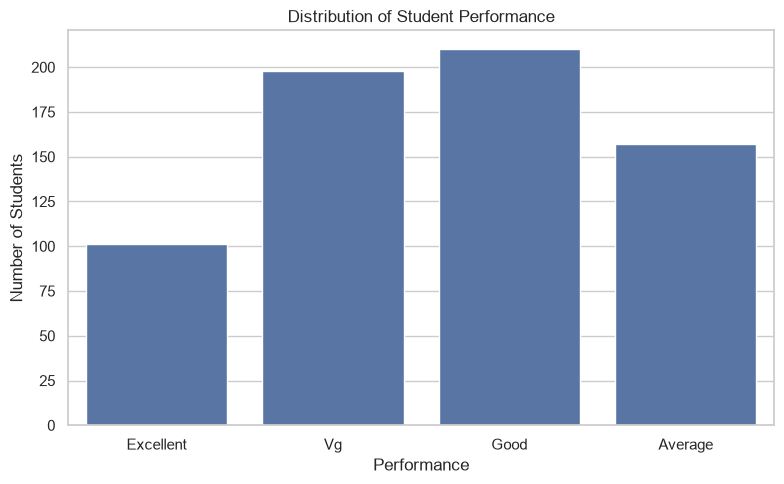

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance"
)

plt.title("Distribution of Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [112]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
[]


In [113]:
print(df[["Class_X_Percentage", "Class_XII_Percentage"]].head())

  Class_X_Percentage Class_XII_Percentage
0          Excellent            Excellent
1          Excellent            Excellent
2          Excellent            Excellent
3          Excellent            Excellent
4          Excellent            Excellent


In [114]:
# Check number of duplicate rows
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before removal: 0
Duplicate rows after removal: 0
New dataset shape: (622, 12)


In [115]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

print(missing_percentage)

Performance             0.0
Gender                  0.0
Caste                   0.0
Coaching                0.0
Time                    0.0
Class_Ten_Education     0.0
Twelve_Education        0.0
Medium                  0.0
Class_X_Percentage      0.0
Class_XII_Percentage    0.0
Father_Occupation       0.0
Mother_Occupation       0.0
dtype: float64


In [116]:
df.describe(include="all").T

,count,unique,top,freq
Performance,622,4,Good,194
Gender,622,2,male,334
Caste,622,4,General,299
Coaching,622,3,WA,413
Time,622,6,TWO,339
Class_Ten_Education,622,3,SEBA,375
Twelve_Education,622,3,AHSEC,348
Medium,622,3,ENGLISH,495
Class_X_Percentage,622,4,Excellent,469
Class_XII_Percentage,622,4,Excellent,362


In [117]:
print(df["Performance"].value_counts())

print("\nPercentage Distribution:")
print(
    df["Performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Performance
Good         194
Vg           178
Average      152
Excellent     98
Name: count, dtype: int64

Percentage Distribution:
Performance
Good         31.19
Vg           28.62
Average      24.44
Excellent    15.76
Name: proportion, dtype: float64


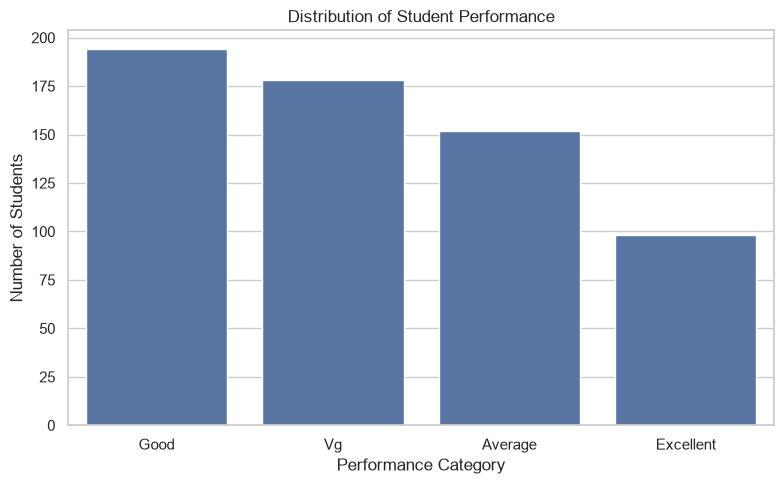

In [118]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance",
    order=df["Performance"].value_counts().index
)

plt.title("Distribution of Student Performance")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.savefig("../outputs/class_distribution.png", dpi=300)
plt.show()

# Exploratory Data Analysis

# gender vs performance 

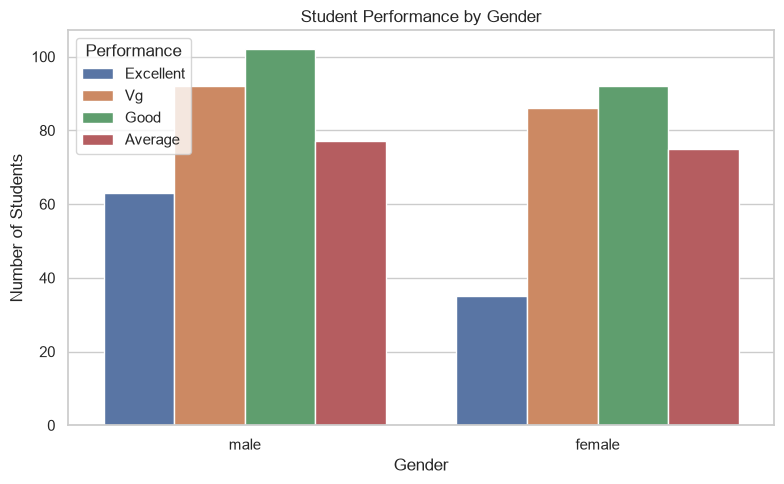

In [119]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Performance"
)

plt.title("Student Performance by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Caste vs Performance 

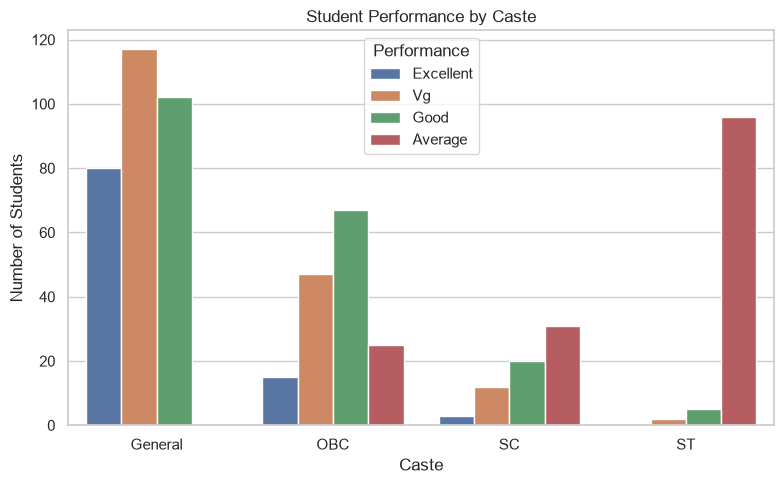

In [120]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Caste",
    hue="Performance"
)

plt.title("Student Performance by Caste")
plt.xlabel("Caste")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Coaching vs Performance 

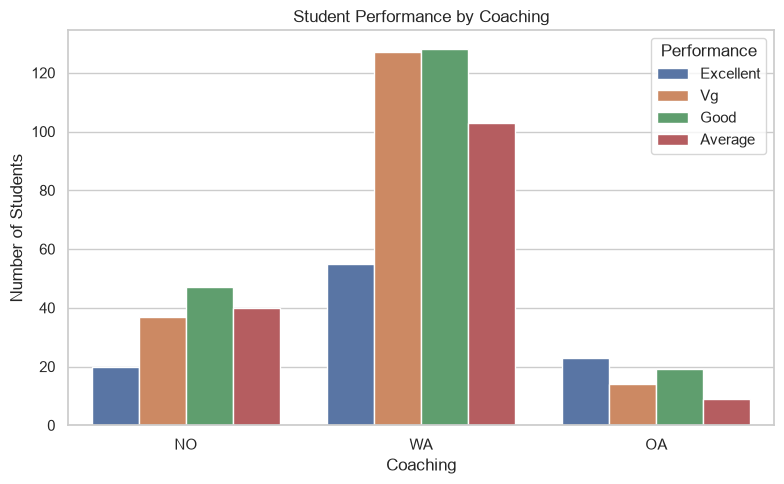

In [121]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Coaching",
    hue="Performance"
)

plt.title("Student Performance by Coaching")
plt.xlabel("Coaching")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Ten education vs Performance

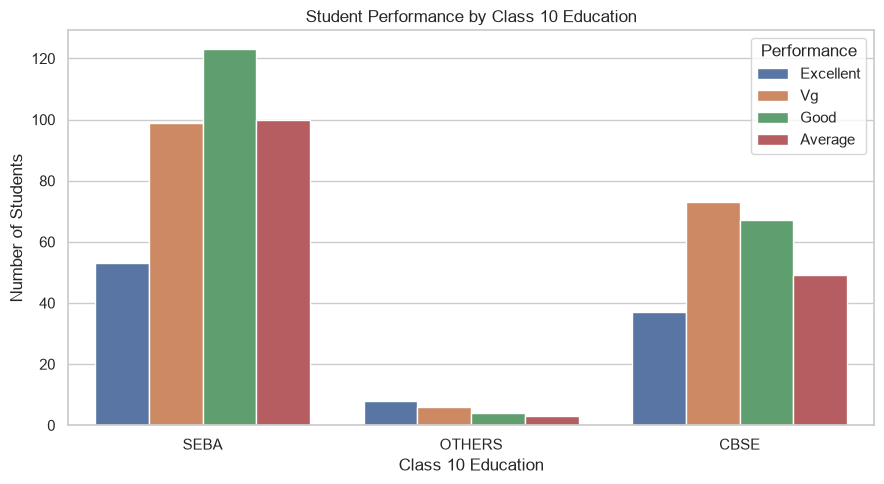

In [122]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Class_Ten_Education",
    hue="Performance"
)

plt.title("Student Performance by Class 10 Education")
plt.xlabel("Class 10 Education")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Twelve education vs Performance 

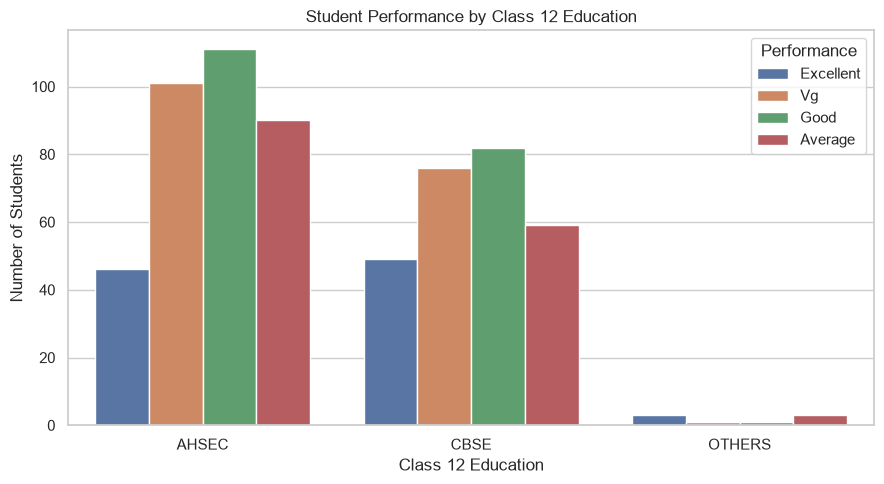

In [123]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Twelve_Education",
    hue="Performance"
)

plt.title("Student Performance by Class 12 Education")
plt.xlabel("Class 12 Education")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Medium vs Performance

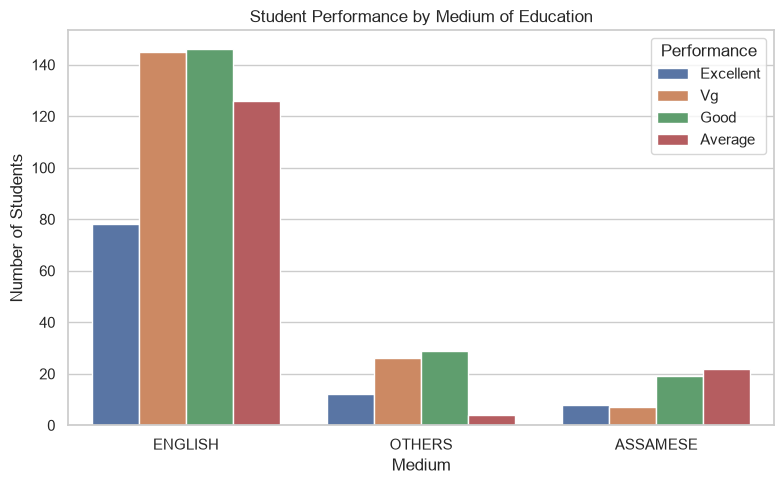

In [124]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Medium",
    hue="Performance"
)

plt.title("Student Performance by Medium of Education")
plt.xlabel("Medium")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Feature vs Target

In [125]:
categorical_features = [
    "Gender",
    "Caste",
    "Coaching",
    "Time",
    "Class_Ten_Education",
    "Twelve_Education",
    "Medium",
    "Class_X_Percentage",
    "Class_XII_Percentage",
    "Father_Occupation",
    "Mother_Occupation"
]

for feature in categorical_features:

    print("\n" + "=" * 70)
    print(feature)

    print(
        pd.crosstab(
            df[feature],
            df["Performance"],
            normalize="index"
        ).round(3)
    )


Gender
Performance  Average  Excellent   Good     Vg
Gender                                       
female         0.260      0.122  0.319  0.299
male           0.231      0.189  0.305  0.275

Caste
Performance  Average  Excellent   Good     Vg
Caste                                        
General        0.000      0.268  0.341  0.391
OBC            0.162      0.097  0.435  0.305
SC             0.470      0.045  0.303  0.182
ST             0.932      0.000  0.049  0.019

Coaching
Performance  Average  Excellent   Good     Vg
Coaching                                     
NO             0.278      0.139  0.326  0.257
OA             0.138      0.354  0.292  0.215
WA             0.249      0.133  0.310  0.308

Time
Performance  Average  Excellent   Good     Vg
Time                                         
FIVE           0.000      0.000  1.000  0.000
FOUR           0.182      0.000  0.455  0.364
ONE            0.243      0.146  0.314  0.297
SEVEN          0.000      0.000  1.000  0.000
THR

In [126]:
X = df.drop("Performance", axis=1)

y = df["Performance"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (622, 11)
y shape: (622,)


In [127]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)
for class_name, class_number in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(class_name, "=", class_number)

Classes:
['Average' 'Excellent' 'Good' 'Vg']
Average = 0
Excellent = 1
Good = 2
Vg = 3


In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 497
Testing samples: 125


In [129]:
categorical_features = X.columns.tolist()

print(categorical_features)

['Gender', 'Caste', 'Coaching', 'Time', 'Class_Ten_Education', 'Twelve_Education', 'Medium', 'Class_X_Percentage', 'Class_XII_Percentage', 'Father_Occupation', 'Mother_Occupation']


In [130]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Logistic Regression Model

In [143]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.504


# Decision Tree Model

In [139]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)

Decision Tree Accuracy: 0.544


# Random Forest Model

In [144]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=3,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.44


# SVM Model

In [145]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                C=1.0,
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

SVM Accuracy: 0.432


# XGBoost Model

In [150]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.01,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softmax",
                num_class=len(label_encoder.classes_),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

XGBoost Accuracy: 0.504


In [151]:
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.544,0.566934,0.544,0.506963
0,Logistic Regression,0.504,0.488800,0.504,0.492885
4,XGBoost,0.504,0.491865,0.504,0.491257
2,Random Forest,0.440,0.414676,0.440,0.422527
3,SVM,0.432,0.391025,0.432,0.406658


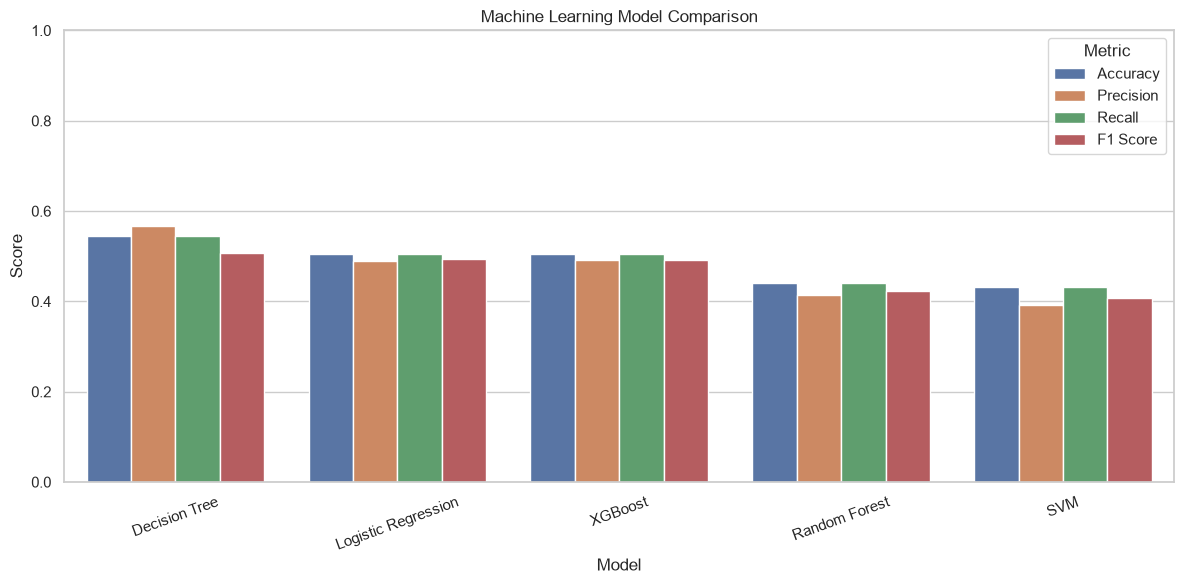

In [152]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=300)
plt.show()

In [153]:
best_model = xgb_model

y_pred_best = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       0.72      0.87      0.79        30
   Excellent       0.45      0.25      0.32        20
        Good       0.42      0.46      0.44        39
          Vg       0.40      0.39      0.39        36

    accuracy                           0.50       125
   macro avg       0.50      0.49      0.49       125
weighted avg       0.49      0.50      0.49       125



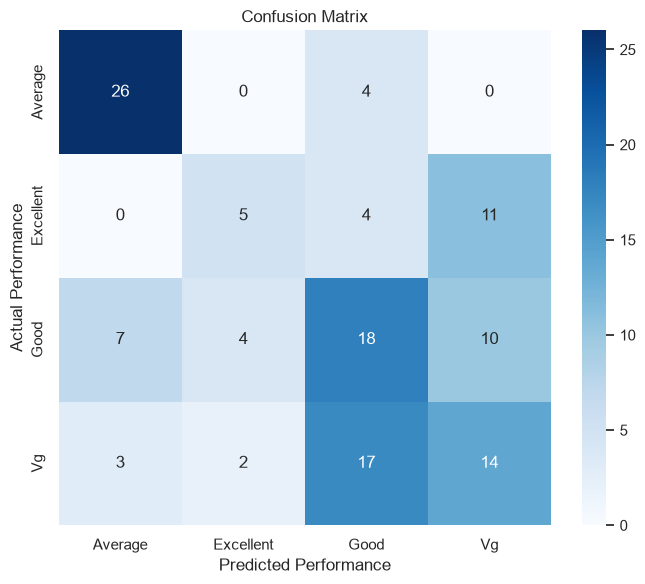

In [154]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Performance")
plt.ylabel("Actual Performance")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=300)
plt.show()

In [155]:
cv_scores = cross_val_score(
    best_model,
    X,
    y_encoded,
    cv=5,
    scoring="f1_weighted"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV F1 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.386573   0.37839812 0.51600677 0.46218007 0.46406819]

Mean CV F1 Score: 0.4414452309017043
Standard Deviation: 0.05193660607549112


In [156]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ass=4, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to

In [158]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

Accuracy: 0.496
Precision: 0.48659047619047624
Recall: 0.496
F1 Score: 0.48551866078626643


In [159]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       0.72      0.87      0.79        30
   Excellent       0.50      0.30      0.38        20
        Good       0.40      0.44      0.42        39
          Vg       0.37      0.36      0.37        36

    accuracy                           0.50       125
   macro avg       0.50      0.49      0.49       125
weighted avg       0.49      0.50      0.49       125



In [160]:
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

feature_names

array(['Gender_female', 'Gender_male', 'Caste_General', 'Caste_OBC',
       'Caste_SC', 'Caste_ST', 'Coaching_NO', 'Coaching_OA',
       'Coaching_WA', 'Time_FOUR', 'Time_ONE', 'Time_SEVEN', 'Time_THREE',
       'Time_TWO', 'Class_Ten_Education_CBSE',
       'Class_Ten_Education_OTHERS', 'Class_Ten_Education_SEBA',
       'Twelve_Education_AHSEC', 'Twelve_Education_CBSE',
       'Twelve_Education_OTHERS', 'Medium_ASSAMESE', 'Medium_ENGLISH',
       'Medium_OTHERS', 'Class_X_Percentage_Average',
       'Class_X_Percentage_Excellent', 'Class_X_Percentage_Good',
       'Class_X_Percentage_Vg', 'Class_XII_Percentage_Average',
       'Class_XII_Percentage_Excellent', 'Class_XII_Percentage_Good',
       'Class_XII_Percentage_Vg', 'Father_Occupation_BANK_OFFICIAL',
       'Father_Occupation_BUSINESS', 'Father_Occupation_COLLEGE_TEACHER',
       'Father_Occupation_CULTIVATOR', 'Father_Occupation_DOCTOR',
       'Father_Occupation_ENGINEER', 'Father_Occupation_OTHERS',
       'Father_Occupation

In [161]:
classifier = best_model.named_steps["classifier"]

importance = classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
5,Caste_ST,0.135087
4,Caste_SC,0.084743
2,Caste_General,0.083445
3,Caste_OBC,0.042810
7,Coaching_OA,0.027895
46,Mother_Occupation_OTHERS,0.024345
20,Medium_ASSAMESE,0.023941
41,Mother_Occupation_COLLEGE_TEACHER,0.022419
30,Class_XII_Percentage_Vg,0.022131
13,Time_TWO,0.021942


In [162]:
from sklearn.model_selection import train_test_split

X = df.drop("Performance", axis=1)
y = df["Performance"]

In [163]:
X_encoded = pd.get_dummies(
    X,
    drop_first=False
)

print("Encoded X shape:", X_encoded.shape)

Encoded X shape: (622, 49)


In [164]:
X_encoded.head()

,Gender_female,Gender_male,Caste_General,Caste_OBC,Caste_SC,Caste_ST,Coaching_NO,Coaching_OA,Coaching_WA,Time_FIVE,...,Father_Occupation_SCHOOL_TEACHER,Mother_Occupation_BANK_OFFICIAL,Mother_Occupation_BUSINESS,Mother_Occupation_COLLEGE_TEACHER,Mother_Occupation_CULTIVATOR,Mother_Occupation_DOCTOR,Mother_Occupation_ENGINEER,Mother_Occupation_HOUSE_WIFE,Mother_Occupation_OTHERS,Mother_Occupation_SCHOOL_TEACHER
0,False,True,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,True,False,True,False,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
2,False,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,True,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True
4,False,True,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (497, 49)
Testing set: (125, 49)


In [166]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(
    random_state=42
)

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10, 15],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}

Best CV F1 Score:
0.5108732312630135


In [167]:
# Best tuned Decision Tree
best_dt = grid_search.best_estimator_

# Predictions on unseen test data
y_pred_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Performance")
print("=" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
))
print("Recall   :", recall_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
))
print("F1 Score :", f1_score(
    y_test, y_pred_dt, average="weighted", zero_division=0
))

Tuned Decision Tree Performance
Accuracy : 0.48
Precision: 0.4714761904761905
Recall   : 0.48
F1 Score : 0.4595103324348607


In [168]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    zero_division=0
))

              precision    recall  f1-score   support

     Average       0.68      0.90      0.77        30
   Excellent       0.33      0.55      0.42        20
        Good       0.46      0.28      0.35        39
          Vg       0.39      0.31      0.34        36

    accuracy                           0.48       125
   macro avg       0.46      0.51      0.47       125
weighted avg       0.47      0.48      0.46       125



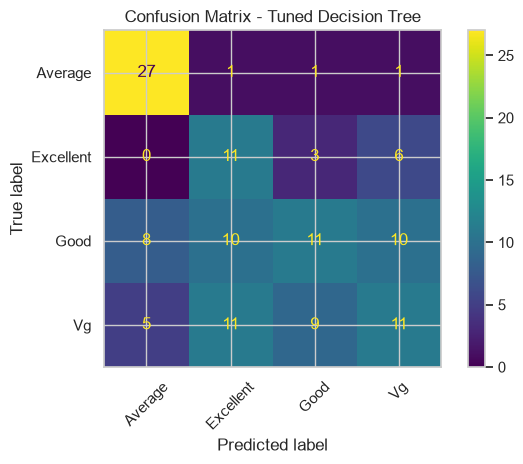

In [169]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="mlogloss"
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got ['Average' 'Excellent' 'Good' 'Vg']

In [171]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df["Performance"])

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Class mapping:
0 = Average
1 = Excellent
2 = Good
3 = Vg


In [175]:
from sklearn.model_selection import train_test_split

X = df.drop("Performance", axis=1)

X_encoded = pd.get_dummies(
    X,
    drop_first=False
)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (497, 49)
Testing data: (125, 49)


In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="mlogloss"
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.504,0.488800,0.504,0.492885
1,XGBoost,0.472,0.453212,0.472,0.460420
2,Random Forest,0.464,0.440334,0.464,0.448004
3,Decision Tree,0.424,0.404034,0.424,0.408919
4,SVM,0.432,0.391025,0.432,0.406658


In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest CV F1 Score:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 1, 'class_weight': None, 'solver': 'lbfgs'}

Best CV F1 Score:
0.49558979558232696


In [178]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Tuned Logistic Regression Performance")
print("=" * 45)

print("Accuracy :", accuracy_score(
    y_test, y_pred_lr
))

print("Precision:", precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
))

print("Recall   :", recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
))

print("F1 Score :", f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
))

Tuned Logistic Regression Performance
Accuracy : 0.504
Precision: 0.48879978558027337
Recall   : 0.504
F1 Score : 0.4928848484848485


In [179]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_order = [
    ["Average", "Good", "Vg", "Excellent"]
]

In [180]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       0.75      0.90      0.82        30
   Excellent       0.38      0.40      0.39        20
        Good       0.43      0.38      0.41        39
          Vg       0.27      0.25      0.26        36

    accuracy                           0.47       125
   macro avg       0.46      0.48      0.47       125
weighted avg       0.45      0.47      0.46       125



In [181]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_lr,
    "../models/tuned_logistic_regression.pkl"
)

print("Tuned Logistic Regression model saved successfully!")

Tuned Logistic Regression model saved successfully!


In [182]:
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [183]:
import os

print(os.path.exists("../models/tuned_logistic_regression.pkl"))
print(os.path.exists("../models/label_encoder.pkl"))

True
True


In [184]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

Performance
<ArrowStringArray>
['Excellent', 'Vg', 'Good', 'Average']
Length: 4, dtype: str

Gender
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Caste
<ArrowStringArray>
['General', 'OBC', 'SC', 'ST']
Length: 4, dtype: str

Coaching
<ArrowStringArray>
['NO', 'WA', 'OA']
Length: 3, dtype: str

Time
<ArrowStringArray>
['ONE', 'TWO', 'THREE', 'FOUR', 'FIVE', 'SEVEN']
Length: 6, dtype: str

Class_Ten_Education
<ArrowStringArray>
['SEBA', 'OTHERS', 'CBSE']
Length: 3, dtype: str

Twelve_Education
<ArrowStringArray>
['AHSEC', 'CBSE', 'OTHERS']
Length: 3, dtype: str

Medium
<ArrowStringArray>
['ENGLISH', 'OTHERS', 'ASSAMESE']
Length: 3, dtype: str

Class_X_Percentage
<ArrowStringArray>
['Excellent', 'Vg', 'Good', 'Average']
Length: 4, dtype: str

Class_XII_Percentage
<ArrowStringArray>
['Excellent', 'Vg', 'Good', 'Average']
Length: 4, dtype: str

Father_Occupation
<ArrowStringArray>
[         'DOCTOR',  'SCHOOL_TEACHER',        'BUSINESS', 'COLLEGE_TEACHER',
          'OTHERS',

In [185]:
import joblib

joblib.dump(
    X_encoded.columns.tolist(),
    "../models/feature_columns.pkl"
)

print("Feature columns saved!")
print("Number of features:", len(X_encoded.columns))

Feature columns saved!
Number of features: 49


In [186]:
for col in df.columns:
    if col != "Performance":
        print("\n", col)
        print(df[col].unique())


 Gender
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

 Caste
<ArrowStringArray>
['General', 'OBC', 'SC', 'ST']
Length: 4, dtype: str

 Coaching
<ArrowStringArray>
['NO', 'WA', 'OA']
Length: 3, dtype: str

 Time
<ArrowStringArray>
['ONE', 'TWO', 'THREE', 'FOUR', 'FIVE', 'SEVEN']
Length: 6, dtype: str

 Class_Ten_Education
<ArrowStringArray>
['SEBA', 'OTHERS', 'CBSE']
Length: 3, dtype: str

 Twelve_Education
<ArrowStringArray>
['AHSEC', 'CBSE', 'OTHERS']
Length: 3, dtype: str

 Medium
<ArrowStringArray>
['ENGLISH', 'OTHERS', 'ASSAMESE']
Length: 3, dtype: str

 Class_X_Percentage
<ArrowStringArray>
['Excellent', 'Vg', 'Good', 'Average']
Length: 4, dtype: str

 Class_XII_Percentage
<ArrowStringArray>
['Excellent', 'Vg', 'Good', 'Average']
Length: 4, dtype: str

 Father_Occupation
<ArrowStringArray>
[         'DOCTOR',  'SCHOOL_TEACHER',        'BUSINESS', 'COLLEGE_TEACHER',
          'OTHERS',   'BANK_OFFICIAL',        'ENGINEER',      'CULTIVATOR']
Length: 8, dtype: str

 